In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

import tsfel

In [25]:
# Load provided features
X_train = pd.read_csv(
    r"UCI HAR Dataset\UCI HAR Dataset\train\X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    r"UCI HAR Dataset\UCI HAR Dataset\train\y_train.txt",
    header=None
).values.ravel()

X_test = pd.read_csv(
    r"UCI HAR Dataset\UCI HAR Dataset\test\X_test.txt",
    sep=r"\s+",
    header=None
)

y_test = pd.read_csv(
    r"UCI HAR Dataset\UCI HAR Dataset\test\y_test.txt",
    header=None
).values.ravel()

In [8]:
X_train.shape , y_train.shape, X_test.shape, y_test.shape

((7352, 561), (7352,), (2947, 561), (2947,))

In [26]:
# Load activity labels
activity_labels = pd.read_csv(r"UCI HAR Dataset\UCI HAR Dataset\activity_labels.txt",
                              sep='\s+', header=None, index_col=0)[1].to_dict()

print(activity_labels)


{1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}


<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\prath\AppData\Local\Temp\ipykernel_30596\3946443044.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  sep='\s+', header=None, index_col=0)[1].to_dict()


In [27]:
from sklearn.decomposition import PCA


**PROVIDED FEATURES**

Decision Tree (Provided Features):
Accuracy: 0.8622
Precision: 0.8633
Recall: 0.8622


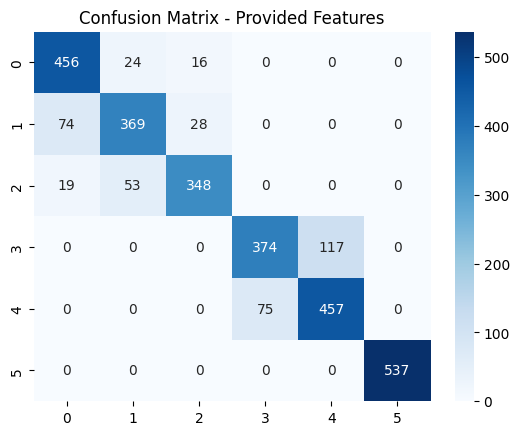

In [28]:
# [6]
# -----------------------------
# 1. Decision Tree using provided features
# -----------------------------

dt_provided = DecisionTreeClassifier(random_state=42)
dt_provided.fit(X_train, y_train)

y_pred_provided = dt_provided.predict(X_test)

acc_provided = accuracy_score(y_test, y_pred_provided)
prec_provided = precision_score(y_test, y_pred_provided, average='weighted')
rec_provided = recall_score(y_test, y_pred_provided, average='weighted')
cm_provided = confusion_matrix(y_test, y_pred_provided)

print("Decision Tree (Provided Features):")
print(f"Accuracy: {acc_provided:.4f}")
print(f"Precision: {prec_provided:.4f}")
print(f"Recall: {rec_provided:.4f}")

sns.heatmap(cm_provided, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Provided Features")
plt.show()


**RAW ACCELEROMETER**

<>:16: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:20: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:16: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:20: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\prath\AppData\Local\Temp\ipykernel_30596\3678169875.py:16: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  sep='\s+', header=None)
C:\Users\prath\AppData\Local\Temp\ipykernel_30596\3678169875.py:20: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not 

Raw accelerometer shape: (7352, 384) (2947, 384)
Decision Tree (Raw Accelerometer Data):
Accuracy: 0.7058
Precision: 0.7065
Recall: 0.7058


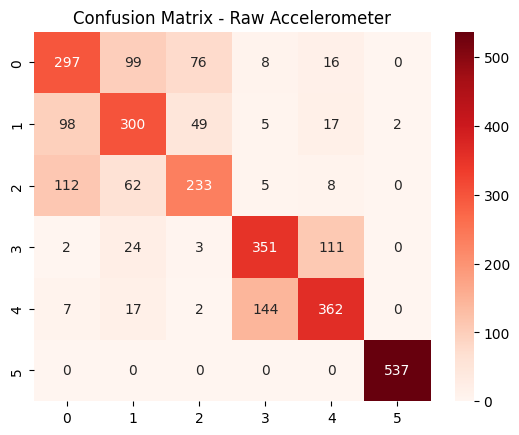

In [29]:
# [7]
# -----------------------------
# 2. Decision Tree using raw accelerometer data
# -----------------------------
# Load raw signals (accelerometer only, total_acc_x, y, z)
# Each file = (samples, 128 readings per window)

import os

signal_types = ["total_acc_x", "total_acc_y", "total_acc_z"]
X_train_raw, X_test_raw = [], []

for signal in signal_types:
    X_train_raw.append(
        pd.read_csv(f"UCI HAR Dataset/UCI HAR Dataset/train/Inertial Signals/{signal}_train.txt",
                    sep='\s+', header=None)
    )
    X_test_raw.append(
        pd.read_csv(f"UCI HAR Dataset/UCI HAR Dataset/test/Inertial Signals/{signal}_test.txt",
                    sep='\s+', header=None)
    )

# Concatenate all 3 axes
X_train_raw = pd.concat(X_train_raw, axis=1)
X_test_raw = pd.concat(X_test_raw, axis=1)

print("Raw accelerometer shape:", X_train_raw.shape, X_test_raw.shape)

# Train Decision Tree
dt_raw = DecisionTreeClassifier(random_state=42)
dt_raw.fit(X_train_raw, y_train)
y_pred_raw = dt_raw.predict(X_test_raw)

acc_raw = accuracy_score(y_test, y_pred_raw)
prec_raw = precision_score(y_test, y_pred_raw, average='weighted')
rec_raw = recall_score(y_test, y_pred_raw, average='weighted')
cm_raw = confusion_matrix(y_test, y_pred_raw)

print("Decision Tree (Raw Accelerometer Data):")
print(f"Accuracy: {acc_raw:.4f}")
print(f"Precision: {prec_raw:.4f}")
print(f"Recall: {rec_raw:.4f}")

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - Raw Accelerometer")
plt.show()


Here by using raw accelarometer data  we get good accuracy in class 6 and overall great accuracy of 0.70508


In [14]:
import pandas as pd

# Each row = 1 sample, each column = 1 timestep
acc_train_x = pd.read_csv(r'UCI HAR Dataset\UCI HAR Dataset\train\Inertial Signals/body_acc_x_train.txt', sep='\s+', header=None)
acc_train_y = pd.read_csv(r'UCI HAR Dataset\UCI HAR Dataset\train\Inertial Signals/body_acc_y_train.txt', sep='\s+', header=None)
acc_train_z = pd.read_csv(r'UCI HAR Dataset\UCI HAR Dataset\train\Inertial Signals/body_acc_z_train.txt', sep='\s+', header=None)

acc_test_x = pd.read_csv(r'UCI HAR Dataset\UCI HAR Dataset\test\Inertial Signals\body_acc_x_test.txt', sep='\s+', header=None)
acc_test_y = pd.read_csv(r'UCI HAR Dataset\UCI HAR Dataset\test\Inertial Signals\body_acc_y_test.txt', sep='\s+', header=None)
acc_test_z = pd.read_csv(r'UCI HAR Dataset\UCI HAR Dataset\test\Inertial Signals\body_acc_z_test.txt', sep='\s+', header=None)


<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:5: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:4: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not 

In [30]:
print("Train shapes:", acc_train_x.shape, acc_train_y.shape, acc_train_z.shape)

Train shapes: (7352, 128) (7352, 128) (7352, 128)


**TSFEL**

In [16]:
import tsfel
cfg = tsfel.get_features_by_domain()


In [31]:
def extract_features_axis(df):
    features = []

    for i in range(len(df)):
        signal = df.iloc[i].to_frame(name="signal")

        feat = tsfel.time_series_features_extractor(
            cfg,
            signal,
            fs=50,
            verbose=0
        )

        features.append(feat)

    return pd.concat(features, ignore_index=True)

In [32]:
x_train_feat = extract_features_axis(acc_train_x).add_prefix("x_")
y_train_feat = extract_features_axis(acc_train_y).add_prefix("y_")
z_train_feat = extract_features_axis(acc_train_z).add_prefix("z_")

In [33]:
X_train_feats = pd.concat(
    [x_train_feat, y_train_feat, z_train_feat],
    axis=1
)

In [34]:
x_test_feat = extract_features_axis(acc_test_x).add_prefix("x_")
y_test_feat = extract_features_axis(acc_test_y).add_prefix("y_")
z_test_feat = extract_features_axis(acc_test_z).add_prefix("z_")

X_test_feats = pd.concat(
    [x_test_feat, y_test_feat, z_test_feat],
    axis=1
)

In [35]:
import numpy as np

X_train_feats = X_train_feats.replace([np.inf, -np.inf], np.nan)
X_test_feats = X_test_feats.replace([np.inf, -np.inf], np.nan)

# Drop columns containing NaNs
valid_cols = X_train_feats.columns[X_train_feats.notna().all()]

X_train_feats = X_train_feats[valid_cols]
X_test_feats = X_test_feats[valid_cols]

# Remove constant features
valid_cols = X_train_feats.columns[X_train_feats.var() > 0]

X_train_feats = X_train_feats[valid_cols]
X_test_feats = X_test_feats[valid_cols]

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_feats = scaler.fit_transform(X_train_feats)
X_test_feats = scaler.transform(X_test_feats)

Decision Tree (TSFEL Features):
Accuracy: 0.7190
Precision: 0.7210
Recall: 0.7190


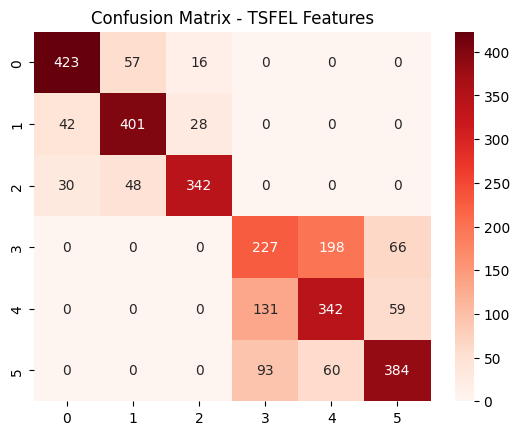

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_feats, y_train)

y_pred_feat = dt.predict(X_test_feats)

acc_feat = accuracy_score(y_test, y_pred_feat)
prec_feat = precision_score(y_test, y_pred_feat, average='weighted')
rec_feat = recall_score(y_test, y_pred_feat, average='weighted')
cm_feat = confusion_matrix(y_test, y_pred_feat)

print("Decision Tree (TSFEL Features):")
print(f"Accuracy: {acc_feat:.4f}")
print(f"Precision: {prec_feat:.4f}")
print(f"Recall: {rec_feat:.4f}")

sns.heatmap(cm_feat, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - TSFEL Features")
plt.show()